In [18]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [19]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [20]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [21]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="llama-3.1-8b-instant")
llm_groq.invoke("Hey I am Vignay and i like to play cricket")

AIMessage(content="Nice to meet you, Vignay! Cricket is a fantastic sport, isn't it? There's something about the thrill of hitting a six, the skill of taking a wicket, and the camaraderie of playing with friends that makes it so enjoyable.\n\nAre you an avid cricket fan, or do you play the sport regularly? Do you have a favorite team, player, or type of cricket (Test, One-Day Internationals, or Twenty20)?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 47, 'total_tokens': 142, 'completion_time': 0.129646744, 'completion_tokens_details': None, 'prompt_time': 0.003074486, 'prompt_tokens_details': None, 'queue_time': 0.049326004, 'total_time': 0.13272123}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4123-e104-7a42-ad04-87118a3a7fe9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'i

In [22]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

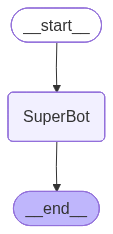

In [23]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [24]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Vignay And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Vignay And I like cricket', additional_kwargs={}, response_metadata={}, id='e3f04706-2546-4b64-b765-cd4f61294b26'),
  AIMessage(content='Nice to meet you, Vignay! Cricket is a fantastic sport with a huge following worldwide. Which team or player is your favorite in international or domestic cricket? Are you more into Test matches, ODIs, or T20s?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 47, 'total_tokens': 96, 'completion_time': 0.085042238, 'completion_tokens_details': None, 'prompt_time': 0.003729757, 'prompt_tokens_details': None, 'queue_time': 0.051493292, 'total_time': 0.088771995}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4123-e781-71d3-baaa-5ef1ca978acc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.



In [26]:
 # Create a thread
config = {"configurable": {"thread_id": "2"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Vignay And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Nice to meet you Vignay. Cricket is a great sport to follow, with many exciting moments and thrilling matches. Do you have a favorite format of the game - Test cricket, One-Day Internationals, or Twenty20?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 140, 'total_tokens': 188, 'completion_time': 0.085579865, 'completion_tokens_details': None, 'prompt_time': 0.008816319, 'prompt_tokens_details': None, 'queue_time': 0.049653851, 'total_time': 0.094396184}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f412b-f0fd-7042-896c-29b26388da91-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 140, 'output_tokens': 48, 'total_tokens': 188})]}}


In [35]:
 # Create a thread
config = {"configurable": {"thread_id": "2"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Vignay And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Vignay And I like cricket', additional_kwargs={}, response_metadata={}, id='aa8c644d-599e-4f40-8a73-1e1fcec86352'), AIMessage(content="Hello Vignay, nice to meet you. It's great to hear that you like cricket. Cricket is a fascinating sport with a rich history and a massive global following. Are you a fan of any particular team or player? Do you enjoy watching Test matches, One-Day Internationals (ODIs), or Twenty20 (T20) cricket?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 47, 'total_tokens': 119, 'completion_time': 0.089539298, 'completion_tokens_details': None, 'prompt_time': 0.002925687, 'prompt_tokens_details': None, 'queue_time': 0.053370893, 'total_time': 0.092464985}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4129-5d8c-7482-96

In [36]:
 # Create a thread
config = {"configurable": {"thread_id": "2"}}

for chunk in graph_builder.stream({'messages':"I also  like football  "},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="So you still enjoy football, Vignay. It seems like it's a sport that you're passionate about. Let's get back to a question about cricket. Have you ever been to a live cricket match, or is there a particular stadium that you'd love to visit for a match someday?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 769, 'total_tokens': 830, 'completion_time': 0.111500785, 'completion_tokens_details': None, 'prompt_time': 0.051164981, 'prompt_tokens_details': None, 'queue_time': 0.049443938, 'total_time': 0.162665766}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f412f-9202-7eb1-91b8-0ec40b507ff4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 769, 'output_tokens': 61, 'total_tokens': 830})]}}


In [37]:
 # Create a thread
config = {"configurable": {"thread_id": "2"}}

for chunk in graph_builder.stream({'messages':"I love sports  "},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Vignay And I like cricket', additional_kwargs={}, response_metadata={}, id='aa8c644d-599e-4f40-8a73-1e1fcec86352'), AIMessage(content="Hello Vignay, nice to meet you. It's great to hear that you like cricket. Cricket is a fascinating sport with a rich history and a massive global following. Are you a fan of any particular team or player? Do you enjoy watching Test matches, One-Day Internationals (ODIs), or Twenty20 (T20) cricket?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 47, 'total_tokens': 119, 'completion_time': 0.089539298, 'completion_tokens_details': None, 'prompt_time': 0.002925687, 'prompt_tokens_details': None, 'queue_time': 0.053370893, 'total_time': 0.092464985}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f4129-5d8c-7482-96

#### Streaming The Responses With astream Method

**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Containslanggraph_node, the node emitting the event.

In [ ]:
config = {"configurable": {"thread_id": "3"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Vignay and I like to play cricket"]},config,version="v2"):
    print(event)
#generally used for streaming provides more than graphstate

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Vignay and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f4135-0d15-7760-805a-0f03531e9a3c', 'metadata': {'thread_id': '3'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Vignay and I like to play cricket', additional_kwargs={}, response_metadata={}, id='5a699c92-c18d-4dac-97ca-a0fe206c6b4f')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019f4135-0d31-75e1-ad9c-703162a39c6c', 'metadata': {'thread_id': '3', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:b7545d52-3424-4d06-7223-a885015c3694'}, 'parent_ids': ['019f4135-0d15-7760-805a-0f03531e9a3c']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='Hi My name is Vignay and I like to 

In [ ]:
s2